# Some plots for visualisation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import prettytable

from contextuality.empirical_model import EmpiricalModel
from contextuality.measurement_scenario import MeasurementScenarioImplementations

from contextuality.utils import compute_deterministic_fraction

## Some definitions

MS = Maximally Signalling
CHSH = Clauser-Horne-Shimony-Holt
PR-Box = Popescu-Rohrlich box

In [2]:
chsh = MeasurementScenarioImplementations.CHSH()
MS_points = [
    np.array([1, 0, 0, 0,
              1, 0, 0, 0,
              1, 0, 0, 0,
              0, 1, 0, 0]),
    np.array([0, 0, 0, 1,
              0, 0, 0, 1,
              0, 0, 0, 1,
              0, 0, 1, 0]),
    np.array([0, 0, 1, 0,
              0, 0, 1, 0,
              0, 0, 1, 0,
              0, 0, 0, 1]),
    np.array([0, 1, 0, 0,
              0, 1, 0, 0,
              0, 1, 0, 0,
              1, 0, 0, 0])
]

PRBOX = np.array([
    1 / 2, 0, 0, 1 / 2,
    1 / 2, 0, 0, 1 / 2,
    1 / 2, 0, 0, 1 / 2,
    0, 1 / 2, 1 / 2, 0
])

FULLY_MIXED = np.array([
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4
])

In [3]:
nb_points = 100

x_range = np.linspace(0, 1, nb_points)
y_range = np.linspace(0, 1, nb_points)

CFs = np.zeros((nb_points, nb_points))
SFs = np.zeros((nb_points, nb_points))
NODFs = np.zeros((nb_points, nb_points))

## Computations
Loop over to get the contextual fraction

In [4]:
y_range_tqdm = tqdm(total=nb_points)
x_range_tqdm = tqdm(total=nb_points)

for i, y in enumerate(y_range):
    x_range_tqdm.reset()
    y_range_tqdm.update()
    p1 = (1 - y) * MS_points[0] + y * MS_points[1]
    p2 = (1 - y) * MS_points[2] + y * MS_points[3]
    for j, x in enumerate(x_range):
        x_range_tqdm.update()
        p = (1 - x) * p1 + x * p2
        em = EmpiricalModel(chsh, p)
        CFs[j, i] = em.compute_cf()["CF"]
        SFs[j, i] = em.compute_sf()["SF"]
        NODFs[j, i] = compute_deterministic_fraction(em)["NOD"]

x_range_tqdm.close()
y_range_tqdm.close()

100%|██████████| 100/100 [03:37<00:00,  2.17s/it]


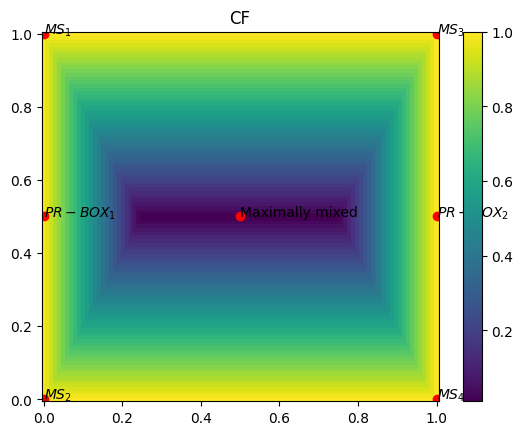

In [5]:
X, Y = np.meshgrid(x_range, y_range)

plt.pcolor(X, Y, CFs.T)
plt.colorbar()

remarkable_points = [(0, 0), (0, 1), (1, 0), (1, 1), (0.5, 0.5), (0, 0.5), (1, 0.5)]
annotations = [r"$MS_2$", r"$MS_1$", r"$MS_4$", r"$MS_3$", r"Maximally mixed", r"$PR-BOX_1$", r"$PR-BOX_2$"]

for (x, y), annotation in zip(remarkable_points, annotations):
    plt.scatter(x, y, c="r")
    plt.annotate(annotation, (x, y))

plt.title("CF")

plt.show()

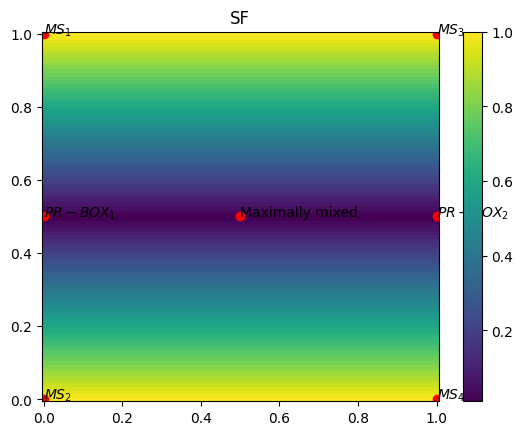

In [6]:
X, Y = np.meshgrid(x_range, y_range)

plt.pcolor(X, Y, SFs.T)
plt.colorbar()

remarkable_points = [(0, 0), (0, 1), (1, 0), (1, 1), (0.5, 0.5), (0, 0.5), (1, 0.5)]
annotations = [r"$MS_2$", r"$MS_1$", r"$MS_4$", r"$MS_3$", r"Maximally mixed", r"$PR-BOX_1$", r"$PR-BOX_2$"]

for (x, y), annotation in zip(remarkable_points, annotations):
    plt.scatter(x, y, c="r")
    plt.annotate(annotation, (x, y))

plt.title("SF")

plt.show()

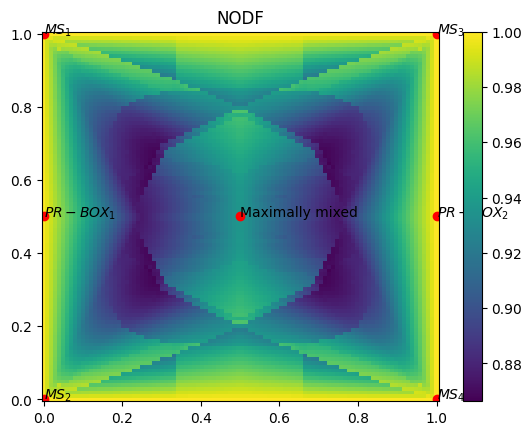

In [7]:
X, Y = np.meshgrid(x_range, y_range)

plt.pcolor(X, Y, NODFs.T)
plt.colorbar()

remarkable_points = [(0, 0), (0, 1), (1, 0), (1, 1), (0.5, 0.5), (0, 0.5), (1, 0.5)]
annotations = [r"$MS_2$", r"$MS_1$", r"$MS_4$", r"$MS_3$", r"Maximally mixed", r"$PR-BOX_1$", r"$PR-BOX_2$"]

for (x, y), annotation in zip(remarkable_points, annotations):
    plt.scatter(x, y, c="r")
    plt.annotate(annotation, (x, y))

plt.title("NODF")

plt.show()

Indication about the annotations

In [8]:
assocations = MS_points + [FULLY_MIXED, PRBOX, 1/2 - PRBOX]
for annotation, assocation in zip(annotations, assocations):
    print(f"============== {annotation} ============== ")
    reshaped_table = assocation.reshape(4,4)
    table = prettytable.PrettyTable()
    table.add_column("A B", ["a b", "a b'", "a' b", "a' b'"])
    table.add_column("00", reshaped_table[:, 0])
    table.add_column("01", reshaped_table[:, 1])
    table.add_column("10", reshaped_table[:, 2])
    table.add_column("11", reshaped_table[:, 3])
    print(table)

============== $MS_2$ ============== 
+-------+----+----+----+----+
|  A B  | 00 | 01 | 10 | 11 |
+-------+----+----+----+----+
|  a b  | 1  | 0  | 0  | 0  |
|  a b' | 1  | 0  | 0  | 0  |
|  a' b | 1  | 0  | 0  | 0  |
| a' b' | 0  | 1  | 0  | 0  |
+-------+----+----+----+----+
============== $MS_1$ ============== 
+-------+----+----+----+----+
|  A B  | 00 | 01 | 10 | 11 |
+-------+----+----+----+----+
|  a b  | 0  | 0  | 0  | 1  |
|  a b' | 0  | 0  | 0  | 1  |
|  a' b | 0  | 0  | 0  | 1  |
| a' b' | 0  | 0  | 1  | 0  |
+-------+----+----+----+----+
============== $MS_4$ ============== 
+-------+----+----+----+----+
|  A B  | 00 | 01 | 10 | 11 |
+-------+----+----+----+----+
|  a b  | 0  | 0  | 1  | 0  |
|  a b' | 0  | 0  | 1  | 0  |
|  a' b | 0  | 0  | 1  | 0  |
| a' b' | 0  | 0  | 0  | 1  |
+-------+----+----+----+----+
============== $MS_3$ ============== 
+-------+----+----+----+----+
|  A B  | 00 | 01 | 10 | 11 |
+-------+----+----+----+----+
|  a b  | 0  | 1  | 0  | 0  |
|  a b' 